# Importations

In [1]:
# Numerical and scientific python programming
import numpy as np

import matplotlib.pyplot as plt

# Auxiliary python functions
import time

# Local importations
from moments.bloch import compute_pauli_basis, compute_tensor_basis, compute_subset_index_map
from moments.optimization import optimize_moment_preserving_entanglement

# Hilbert apace definition

In [2]:
N = 2
d = 2 ** N

pauli_basis = compute_pauli_basis()
local_bases = [pauli_basis.copy()] * N
local_basis_sizes = [len(basis) for basis in local_bases]

tensor_basis = compute_tensor_basis(local_bases)
subset_index_map = compute_subset_index_map(local_basis_sizes)

## Analytical conditions

In general, the 3D region explored consits of a subset of $\mathbb R^3$ that satisfy certain constraints.
In particular, those are

- $x, y, z \ge 0$,
- $z \ge x + y - 1$,
- $z^2 \le 3 + x^2 + y^2 - 4xy - 4|x-y|$,

By setting $y = 0$ the inequalities become:

- $x, z \ge 0$,
- $z \ge x - 1$,
- $z^2 \le 3 + x^2 - 4x$.

Similarly, we can first write down the iniqualities that difine the entangled, mixed and separable regions:

- Entangled: $z^2 > 1 - |x^2 - y^2|$;
- Separable: $z \le \begin{cases} \sqrt{\frac16 [2 - 3 (x + y)^2]} & x + y \le \frac23 \, , \\ 1 - x - y & \frac23 < x + y \le 1 \, ,  \\ x + y - 1 & 1 < x + y \, . \end{cases}$

Which again can be simplified for the case of interest:

- Entangled: $z^2 > 1 - x^2$;
- Separable: $z \le \begin{cases} \sqrt{\frac16 [2 - 3 x^2]} & x \le \frac23 \, , \\ 1 - x & \frac23 < x \le 1 \, . \end{cases}$


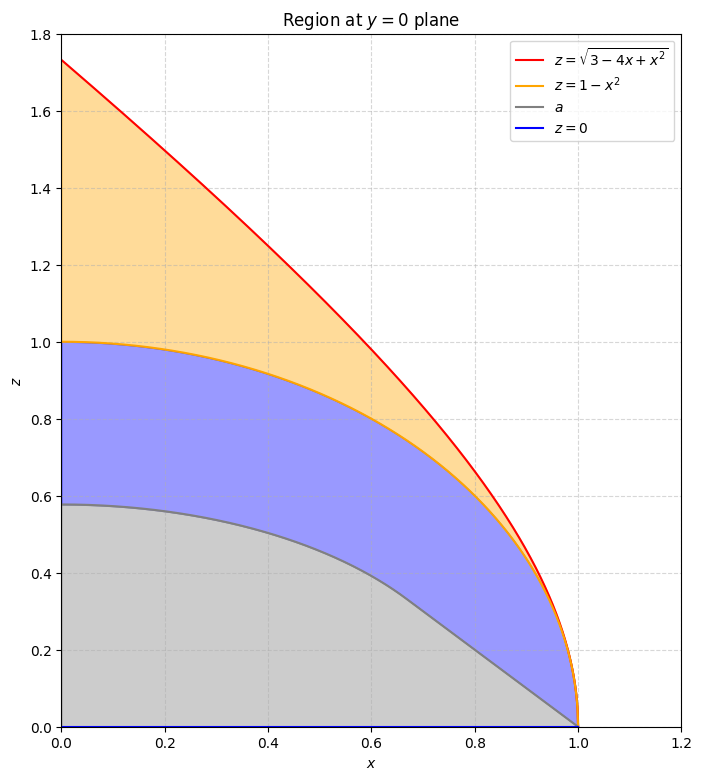

In [3]:
x = np.linspace(0, 1, 1000)

z_upper = np.sqrt(3 - 4*x + x**2)
z_ent = np.sqrt(1 - x**2)
z_sep = np.piecewise(x, [x <= 2/3, x > 2/3],
                     [lambda x: np.sqrt(1/6 * (2 - 3 * x**2)), lambda x: 1 - x])
z_lower = np.zeros_like(x)

fig, ax = plt.subplots(figsize=(8, 9))

ax.fill_between(x, z_upper, z_ent, alpha=0.4, color='orange')
ax.fill_between(x, z_ent, z_sep, alpha=0.4, color='blue')
ax.fill_between(x, z_sep, z_lower, alpha=0.4, color='grey')

ax.plot(x, z_upper, 'red', label=r"$z = \sqrt{3 - 4x + x^2}$")
ax.plot(x, z_ent, 'orange', label=r"$z = 1 - x^2$")
ax.plot(x, z_sep, 'grey', label=f"$a$")
ax.plot(x, z_lower, 'blue', label=r"$z = 0$")



ax.set(xlabel = r'$x$', ylabel = r'$z$', title = 'Region at $y = 0$ plane',
       xlim = (0, 1.2), ylim = (0, 1.8))
ax.grid(True, alpha=0.5, linestyle="--")
ax.legend()
plt.show()

## Moment space discretization

In [4]:
D = 200
Dx, Dz = D + 1, int(np.sqrt(3) * D) + 1

x = np.linspace(0, 1, Dx)
z = np.linspace(0, np.sqrt(3), Dz)

X, Z = np.meshgrid(x, z, indexing='ij')

mask_state = Z**2 <= 3 - 4*X + X**2
indices = np.where(mask_state)
total_points = len(indices[0])

points = np.column_stack((X[mask_state], Z[mask_state]))
print(f"Number of points: {points.shape[0]}")

sep_vals = np.full_like(X, np.nan)
sep_vals[X <= 2/3] = np.sqrt(1/6 * (2 - 3 * X[X <= 2/3]**2))
sep_vals[(X > 2/3)] = 1 - X[(X > 2/3)]

mask_ent = mask_state & (Z**2 > 1 - X**2)
mask_mix = (Z**2 <= 1 - X**2) & (Z > sep_vals)
mask_sep = Z <= sep_vals

Number of points: 43166


## Optimization

In [5]:
def run_easy(d, tensor_basis, subset_index_map, Rt, optimization, max_attempts=5):
    result = None
    for _ in range(max_attempts):
        result = optimize_moment_preserving_entanglement(d, tensor_basis, subset_index_map, Rt,
                                                         metric="concurrence", optimization=optimization, cholesky_opt=True)
        if result.optimizer_info["result_success"]:
            return result
    return result

def run_hard(d, tensor_basis, subset_index_map, Rt, optimization, attempts):
    best_result = None
    best_metric = -np.inf

    for _ in range(attempts):
        result = optimize_moment_preserving_entanglement(d, tensor_basis, subset_index_map, Rt,
                                                         metric="concurrence", optimization=optimization, cholesky_opt=True)
        
        if result.metric_final > best_metric:
            best_metric = result.metric_final
            best_result = result

    return best_result

In [6]:
success, times = [], []
max_ent = np.full_like(X, np.nan, dtype=float)

for counter, (idx, jdx) in enumerate(zip(indices[0], indices[1]), 1):
    t0 = time.time()

    x_val = X[idx, jdx]
    z_val = Z[idx, jdx]

    Rt = {(1,): float(x_val), (2,): 0.0, (1, 2): float(z_val)}
    
    if mask_ent[idx, jdx]:
        optimization_result = run_easy(d, tensor_basis, subset_index_map, Rt, "maximize", max_attempts=5)

    elif mask_mix[idx, jdx]:
        optimization_result = run_hard(d, tensor_basis, subset_index_map, Rt, "maximize", attempts=10)

    elif mask_sep[idx, jdx]:
        optimization_result = run_easy(d, tensor_basis, subset_index_map, Rt, "maximize", max_attempts=5)

    else:
        continue
    
    max_ent[idx, jdx] = optimization_result.metric_final
    success.append(optimization_result.optimizer_info["result_success"])

    tf = time.time()

    times.append(tf-t0)
    
    percent_complete = (counter / total_points) * 100
    print(f"\rProgress: {percent_complete:.2f}% ({counter}/{total_points}) | Time for this point: {tf-t0:.3f} s", end="", flush=True)

print(f"\n\nDone!")
print(f"Successful optimizations: {sum(success)}/{total_points} | Percentage: {sum(success)*100/total_points:.2f} %")
print(f"Total time: {sum(times)/60:.2f} min | Average time per point: {sum(times)/total_points:.3f} s", )

Progress: 100.00% (43166/43166) | Time for this point: 2.422 s

Done!
Successful optimizations: 23233/43166 | Percentage: 53.82 %
Total time: 829.73 min | Average time per point: 1.153 s


In [7]:
success, times = [], []
min_ent = np.full_like(X, np.nan, dtype=float)

for counter, (idx, jdx) in enumerate(zip(indices[0], indices[1]), 1):
    t0 = time.time()

    x_val = X[idx, jdx]
    z_val = Z[idx, jdx]

    Rt = {(1,): float(x_val), (2,): 0.0, (1, 2): float(z_val)}
    
    optimization_result = run_easy(d, tensor_basis, subset_index_map, Rt, "minimize", max_attempts=5)
    
    min_ent[idx, jdx] = optimization_result.metric_final
    success.append(optimization_result.optimizer_info["result_success"])

    tf = time.time()

    times.append(tf-t0)
    
    percent_complete = (counter / total_points) * 100
    print(f"\rProgress: {percent_complete:.2f}% ({counter}/{total_points}) | Time for this point: {tf-t0:.3f} s", end="", flush=True)

print(f"\n\nDone!")
print(f"Successful optimizations: {sum(success)}/{total_points} | Percentage: {sum(success)*100/total_points:.2f} %")
print(f"Total time: {sum(times)/60:.2f} min | Average time per point: {sum(times)/total_points:.3f} s", )

Progress: 13.92% (6009/43166) | Time for this point: 1.826 s s

KeyboardInterrupt: 

## Results

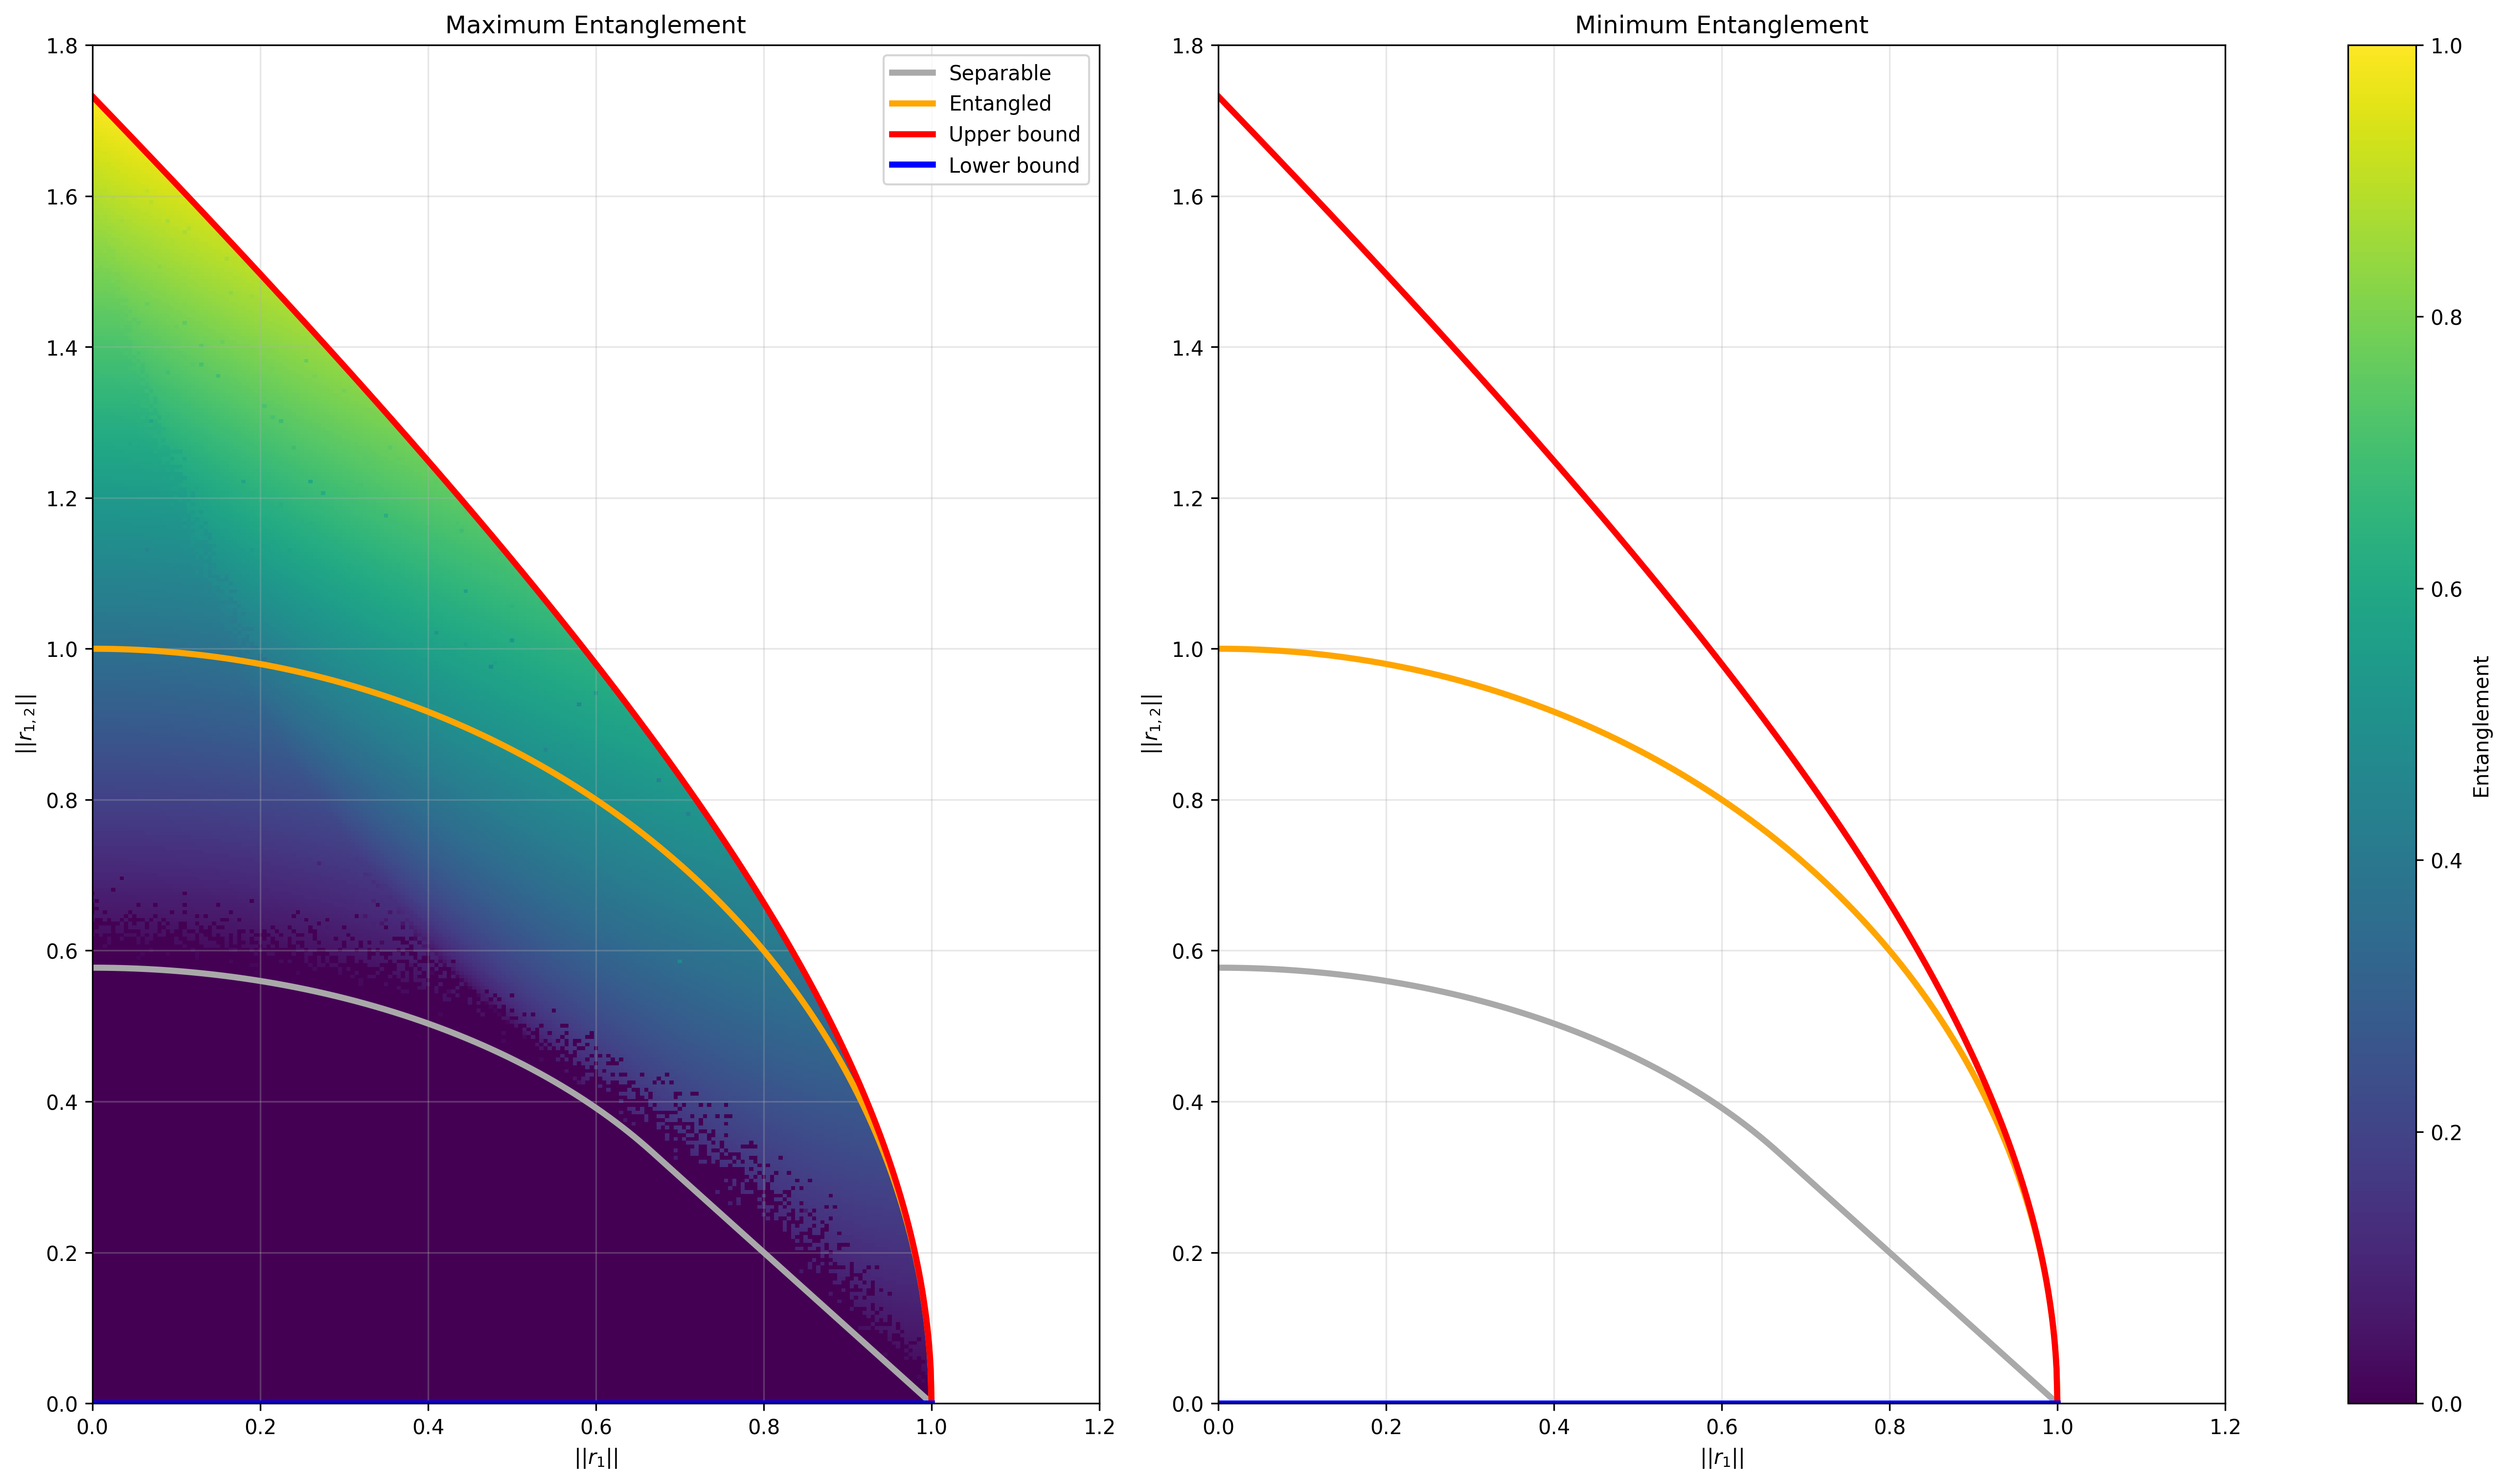

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(17, 10), constrained_layout=True, dpi=300)

mesh0 = ax[0].pcolormesh(X, Z, max_ent, shading='auto', cmap='viridis', vmin=0, vmax=1)
#mesh1 = ax[1].pcolormesh(X, Z, min_ent, shading='auto', cmap='viridis', vmin=0, vmax=1)

cbar = fig.colorbar(mesh0, ax=ax.ravel().tolist(), label='Entanglement', 
                    pad=0.05, aspect=20, shrink=1)

cbar.set_ticks(list(np.linspace(0, 1, 6)))

ax[0].set(xlabel = r"$|| r_1 ||$", ylabel = r"$||r_{1, 2}||$",
xlim = (0, 1.2), ylim = (0, 1.8))
ax[1].set(xlabel = r"$|| r_1 ||$", ylabel = r"$||r_{1, 2}||$",
xlim = (0, 1.2), ylim = (0, 1.8))

ax[0].set_title('Maximum Entanglement')
ax[1].set_title('Minimum Entanglement')

x = np.linspace(0, 1, 1000)
z_upper = np.sqrt(3 - 4*x + x**2)
z_ent = np.sqrt(1 - x**2)
z_sep = np.piecewise(x, [x <= 2/3, x > 2/3],
                     [lambda x: np.sqrt(1/6 * (2 - 3 * x**2)), lambda x: 1 - x])
z_lower = np.zeros_like(x)

ax[0].plot(x, z_sep, 'darkgrey', linewidth=3, label='Separable')
ax[0].plot(x, z_ent, 'orange', linewidth=3, label='Entangled')
ax[0].plot(x, z_upper, 'r', linewidth=3, label='Upper bound')
ax[0].plot(x, z_lower, 'b', linewidth=3, label='Lower bound')

ax[1].plot(x, z_sep, 'darkgrey', linewidth=3, label='Separable')
ax[1].plot(x, z_ent, 'orange', linewidth=3, label='Entangled')
ax[1].plot(x, z_upper, 'r', linewidth=3, label='Upper bound')
ax[1].plot(x, z_lower, 'b', linewidth=3, label='Lower bound')

ax[0].legend(loc='upper right')
ax[0].grid(True, alpha=0.3)
ax[1].grid(True, alpha=0.3)

plt.show()

In [10]:
np.save("max_concurrence", max_ent)
#np.save("mix_concurrence_2q_xz_plane", min_ent)